# ÉquiAlgo : rapport d'audit du biais régional

Ce carnet mesure le biais du modèle de production, justifie le choix des métriques d'équité et identifie les variables proxys. Il ne corrige rien : la correction est dans `model_corrige.py` (dernière cellule).

**Question centrale.** Les candidats des régions éloignées (Bas-Saint-Laurent, Côte-Nord, Gaspésie–Îles-de-la-Madeleine) reçoivent moins de bourses que ceux des centres (Montréal, Capitale-Nationale). L'écart s'explique-t-il par le mérite, ou le comité a-t-il appliqué une pénalité régionale ?

Toutes les données sont synthétiques. Graines fixes ; exécution complète en moins de deux minutes.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time; T0 = time.time()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
C_CENTRE, C_ELOIGNE = '#1f77b4', '#d62728'
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

df = pd.read_csv('data/donnees_demandes.csv')
df['eloigne'] = df['region_administrative'].isin(ELOIGNEES).astype(int)
df['groupe'] = np.where(df['eloigne'] == 1, 'Éloignée', 'Centre')
y = df['decision_octroi'].to_numpy()
e = df['eloigne'].to_numpy()
print(len(df), 'dossiers historiques ;', e.sum(), 'en région éloignée (', f'{e.mean():.1%}', ')')

10000 dossiers historiques ; 4000 en région éloignée ( 40.0% )


## 1. Données et groupes

Dix mille dossiers historiques avec la décision du comité (`decision_octroi`). Deux groupes : *centre* et *régions éloignées*. Intervalles de confiance de Wilson à 95 % : ils tiennent bien pour des proportions et de grands effectifs.

                       region  eloigne    n  taux  ic_bas  ic_haut  cote_r_moy
                    Cote-Nord        1 1178 0.263   0.239    0.289      27.325
            Bas-Saint-Laurent        1 1293 0.269   0.246    0.294      27.296
Gaspesie-Iles-de-la-Madeleine        1 1529 0.284   0.262    0.307      27.354
                     Montreal        0 4001 0.483   0.468    0.499      27.988
           Capitale-Nationale        0 1999 0.484   0.462    0.506      27.984


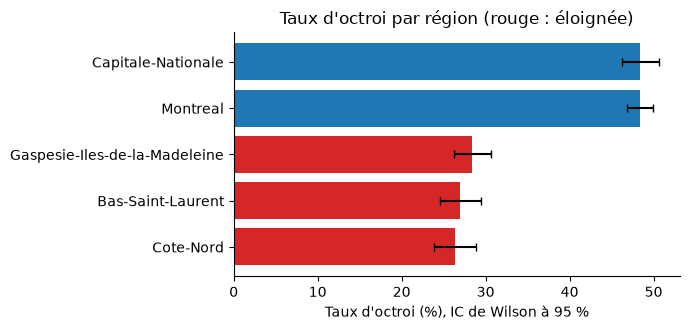

Centre    n= 6000  taux 48.4%  IC [47.1%, 49.6%]  cote R moyenne 27.99
Éloignée  n= 4000  taux 27.3%  IC [25.9%, 28.7%]  cote R moyenne 27.33


In [2]:
def wilson(k, n, z=1.96):
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return p, c - h, c + h

rows = []
for reg, g in df.groupby('region_administrative'):
    p, lo, hi = wilson(g['decision_octroi'].sum(), len(g))
    rows.append((reg, int(g['eloigne'].iloc[0]), len(g), p, lo, hi, g['cote_r_equivalent'].mean()))
reg = pd.DataFrame(rows, columns=['region', 'eloigne', 'n', 'taux', 'ic_bas', 'ic_haut', 'cote_r_moy']).sort_values('taux')
print(reg.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.4))
col = [C_ELOIGNE if v else C_CENTRE for v in reg['eloigne']]
ax.barh(reg['region'], reg['taux'] * 100, color=col,
        xerr=[(reg['taux'] - reg['ic_bas']) * 100, (reg['ic_haut'] - reg['taux']) * 100], capsize=3)
ax.set_xlabel("Taux d'octroi (%), IC de Wilson à 95 %")
ax.set_title("Taux d'octroi par région (rouge : éloignée)")
plt.tight_layout(); plt.show()

for gname in ['Centre', 'Éloignée']:
    g = df[df['groupe'] == gname]
    p, lo, hi = wilson(g['decision_octroi'].sum(), len(g))
    print(f"{gname:9s} n={len(g):5d}  taux {p:.1%}  IC [{lo:.1%}, {hi:.1%}]  cote R moyenne {g['cote_r_equivalent'].mean():.2f}")

Le taux d'octroi est d'environ 48 % dans les deux centres et d'environ 27 % dans les trois régions éloignées. L'écart entre régions d'un même groupe est faible devant l'écart entre groupes : le regroupement en deux blocs est justifié. La cote R moyenne diffère à peine entre groupes (voir ci-dessus), loin de ce qu'il faudrait pour expliquer 21 points.

## 2. Reproduction du modèle de base

Forêt aléatoire entraînée sur toutes les colonnes, comme dans `baseline_model.ipynb` (même découpage 70/30, mêmes hyperparamètres). On vérifie que retirer la région, puis le code postal, ne règle presque rien.

In [3]:
CATEG = ['programme_etudes', 'region_administrative', 'code_postal_3']
base = df.drop(columns=['id_candidat', 'decision_octroi', 'groupe', 'eloigne'])
X_all = pd.get_dummies(base, columns=CATEG)
tr_idx, te_idx = train_test_split(df.index, test_size=0.3, random_state=SEED, stratify=y)
y_tr, y_te = y[tr_idx], y[te_idx]
g_te = e[te_idx]

def ecart_parite(pred, g):
    return pred[g == 0].mean() - pred[g == 1].mean()

def rf_sans(prefixes):
    cols = [c for c in X_all.columns if not c.startswith(tuple(prefixes))] if prefixes else list(X_all.columns)
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=SEED, n_jobs=2)
    m.fit(X_all.loc[tr_idx, cols], y_tr)
    p = m.predict(X_all.loc[te_idx, cols])
    return m, p, cols

rf, pred_rf, cols_rf = rf_sans(())
print(f"Exactitude (vs décisions du comité) : {accuracy_score(y_te, pred_rf):.1%}")
for etiq, pre in [('toutes les colonnes', ()), ('sans région', ('region_administrative_',)),
                  ('sans région ni code postal', ('region_administrative_', 'code_postal_3_'))]:
    _, p, _ = rf_sans(pre)
    print(f"{etiq:30s} exactitude {accuracy_score(y_te, p):.3f}   écart de parité {ecart_parite(p, g_te):.3f}")

Exactitude (vs décisions du comité) : 88.1%


toutes les colonnes            exactitude 0.881   écart de parité 0.188


sans région                    exactitude 0.884   écart de parité 0.180


sans région ni code postal     exactitude 0.880   écart de parité 0.174


Les valeurs reproduisent celles des organisateurs : exactitude de 88,1 % et écart de parité de 0,188 (ci-dessus : 0,180 puis 0,174 après retrait, contre 0,181 et 0,173 chez les organisateurs ; différence de ±0,001 attribuable à la version de scikit-learn). Retirer l'étiquette de région ne retire pas l'information régionale (section 7).

## 3. Pourquoi l'exactitude et le TPR sont trompeurs ici

Exactitude et taux de vrais positifs (TPR) comparent les prédictions à `decision_octroi`, c'est-à-dire aux décisions passées du comité. Si le comité est biaisé, un modèle qui l'imite parfaitement obtient une exactitude et un TPR élevés *et* reproduit le biais. Montrons-le : mesuré contre l'étiquette biaisée, l'écart de TPR entre groupes est bien plus petit que l'écart de parité, et l'exactitude est même un peu meilleure pour le groupe éloigné.

In [4]:
for nom, gv in [('Centre', 0), ('Éloignée', 1)]:
    m = g_te == gv
    print(f"{nom:9s} taux d'octroi prédit {pred_rf[m].mean():.3f} | TPR vs comité {recall_score(y_te[m], pred_rf[m]):.3f}"
          f" | exactitude {accuracy_score(y_te[m], pred_rf[m]):.3f}")
tpr = [recall_score(y_te[g_te == v], pred_rf[g_te == v]) for v in (0, 1)]
print(f"Écart de TPR vs comité : {tpr[0] - tpr[1]:+.3f} ; écart de parité : {ecart_parite(pred_rf, g_te):.3f}")

Centre    taux d'octroi prédit 0.459 | TPR vs comité 0.847 | exactitude 0.878
Éloignée  taux d'octroi prédit 0.271 | TPR vs comité 0.785 | exactitude 0.887
Écart de TPR vs comité : +0.063 ; écart de parité : 0.188


Les « positifs » de l'étiquette sont déjà passés par le filtre biaisé : l'égalité des chances calculée contre `decision_octroi` mesure la fidélité au comité, pas l'équité. Il faut une référence indépendante du comité (mérite, ou comité sans la pénalité). Nous les construisons dans la section 5 et dans `model_corrige.py`.

## 4. Disparité brute

Écart de parité démographique sur les 10 000 dossiers, intervalle bootstrap (2 000 rééchantillonnages) et test de permutation des étiquettes de groupe (10 000 permutations).

In [5]:
d_obs = y[e == 0].mean() - y[e == 1].mean()
n = len(y)
bs = np.empty(2000)
for i in range(2000):
    idx = rng.integers(0, n, n)
    yy, ee = y[idx], e[idx]
    bs[i] = yy[ee == 0].mean() - yy[ee == 1].mean()
lo, hi = np.percentile(bs, [2.5, 97.5])
perm = np.empty(10000)
for i in range(10000):
    ep = rng.permutation(e)
    perm[i] = y[ep == 0].mean() - y[ep == 1].mean()
p_perm = (np.sum(np.abs(perm) >= abs(d_obs)) + 1) / (len(perm) + 1)
print(f"Écart brut centre - éloignée : {d_obs:.3f}  IC bootstrap 95 % [{lo:.3f}, {hi:.3f}]")
print(f"Test de permutation : p = {p_perm:.5f} ; |écart| max sous H0 = {np.abs(perm).max():.3f}")

Écart brut centre - éloignée : 0.211  IC bootstrap 95 % [0.192, 0.229]
Test de permutation : p = 0.00010 ; |écart| max sous H0 = 0.040


L'écart est très éloigné de tout ce que produit le hasard : sous l'hypothèse d'indépendance, aucune permutation n'approche l'écart observé. Reste à savoir si les profils des candidats l'expliquent.

## 5. Expliqué ou inexpliqué ?

**5a. À cote R égale.** Taux d'octroi par tranche de cote R et par groupe. Si le comité jugeait sur le mérite seul, les deux courbes se confondraient.

groupe     Centre  Éloignée  Centre_n  Éloignée_n
tranche_r                                        
(18, 20]      0.0       0.0        19          23
(20, 22]      0.0       0.0       106         129
(22, 24]      0.2       0.0       410         381
(24, 26]      3.0       0.8       996         757
(26, 28]     24.1       6.7      1496        1063
(28, 30]     70.9      40.8      1438         910
(30, 32]     95.8      83.1       986         514
(32, 34]     99.8      98.2       419         165
(34, 36]    100.0     100.0       106          45


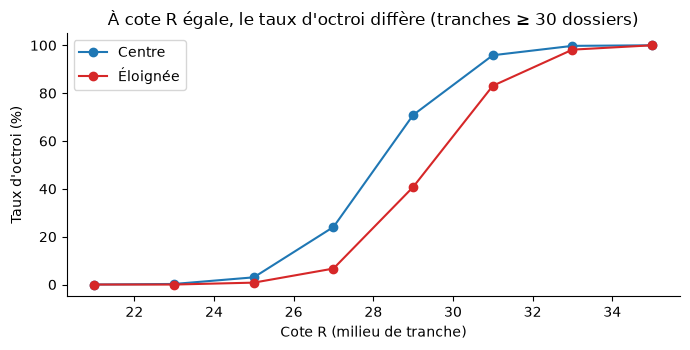

In [6]:
bins = np.arange(18, 38, 2)
df['tranche_r'] = pd.cut(df['cote_r_equivalent'], bins=bins)
tab = df.groupby(['tranche_r', 'groupe'], observed=True)['decision_octroi'].agg(['mean', 'size']).unstack('groupe')
print((tab['mean'] * 100).round(1).join(tab['size'], rsuffix='_n').to_string())

fig, ax = plt.subplots(figsize=(7, 3.6))
for g, c in [('Centre', C_CENTRE), ('Éloignée', C_ELOIGNE)]:
    s = tab[('mean', g)]; nn = tab[('size', g)]
    ok = nn >= 30
    mid = [iv.mid for iv in s.index]
    ax.plot(np.array(mid)[ok], s[ok] * 100, 'o-', color=c, label=g)
ax.set_xlabel('Cote R (milieu de tranche)'); ax.set_ylabel("Taux d'octroi (%)")
ax.set_title("À cote R égale, le taux d'octroi diffère (tranches ≥ 30 dossiers)")
ax.legend(); plt.tight_layout(); plt.show()

**5b. Modèle logistique du comité** avec l'indicateur « éloigné ». Les 8 variables du comité sont standardisées ; le coefficient de l'indicateur éloigné (en log-cotes) est la pénalité régionale, à profil égal. IC par bootstrap (500 rééchantillonnages).

In [7]:
PROG = ['Genie', 'Sante', 'Sciences', 'Sciences sociales']
def feats(d):
    F = pd.DataFrame({'cote_r': d['cote_r_equivalent'], 'log_revenu': np.log(d['revenu_familial_estime']),
                      'heures': d['heures_travail_semaine'], 'premiere_gen': d['premiere_generation_universitaire']}, index=d.index)
    for p in PROG: F['prog_' + p] = (d['programme_etudes'] == p).astype(float)
    return F
F = feats(df); NOMS = list(F.columns)
sc = StandardScaler().fit(F)
Z = sc.transform(F)

def ajuster(Zm, em, ym):
    return LogisticRegression(max_iter=3000).fit(np.column_stack([Zm, em]), ym)

lr = ajuster(Z, e, y)
coef = lr.coef_[0]
pen = coef[-1]
bpen = np.empty(500)
for i in range(500):
    idx = rng.integers(0, n, n)
    bpen[i] = ajuster(Z[idx], e[idx], y[idx]).coef_[0][-1]
plo, phi = np.percentile(bpen, [2.5, 97.5])
print('Coefficients standardisés (log-cotes par écart-type) :')
for nom, c in zip(NOMS + ['ELOIGNE (indicateur)'], coef): print(f'  {nom:22s} {c:+.2f}')
print(f"\nPénalité régionale : {pen:+.2f} log-cotes, IC bootstrap 95 % [{plo:.2f}, {phi:.2f}] ; cotes x {np.exp(pen):.2f}")
print(f"Exactitude du modèle du comité (apprentissage) : {accuracy_score(y, lr.predict(np.column_stack([Z, e]))):.3f}")

Coefficients standardisés (log-cotes par écart-type) :
  cote_r                 +4.12
  log_revenu             +0.80
  heures                 +0.76
  premiere_gen           -0.03
  prog_Genie             +0.02
  prog_Sante             +0.02
  prog_Sciences          +0.01
  prog_Sciences sociales +0.00
  ELOIGNE (indicateur)   -1.90

Pénalité régionale : -1.90 log-cotes, IC bootstrap 95 % [-2.08, -1.72] ; cotes x 0.15
Exactitude du modèle du comité (apprentissage) : 0.887


Lecture : la cote R domine ; le revenu et les heures de travail comptent aussi (le comité récompense l'aisance et le travail, voir limites) ; le programme et la première génération ne pèsent presque rien. L'indicateur « éloigné » porte une pénalité nette, à profil égal, dont l'intervalle exclut zéro.

**5c. Une seule règle pour les deux groupes ?** Test du rapport de vraisemblance : modèle commun (8 variables + indicateur) contre modèle avec interactions éloigné × chaque variable (8 termes de plus, df = 8). `C=np.inf` pour un ajustement sans pénalisation. Si les pentes sont égales, la pénalité est un décalage unique, pas une règle différente par région.

In [8]:
def loglik(Xm):
    m = LogisticRegression(C=np.inf, max_iter=5000).fit(Xm, y)
    p = np.clip(m.predict_proba(Xm)[:, 1], 1e-12, 1 - 1e-12)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
X0 = np.column_stack([Z, e])
X1 = np.column_stack([Z, e, Z * e[:, None]])
ll0, ll1 = loglik(X0), loglik(X1)
lrt = 2 * (ll1 - ll0)
p_lrt = stats.chi2.sf(lrt, df=Z.shape[1])
print(f"LRT : chi2 = {lrt:.2f}, df = {Z.shape[1]}, p = {p_lrt:.3f}")

LRT : chi2 = 4.38, df = 8, p = 0.821


Le test ne rejette pas l'égalité des pentes : le comité applique la *même* règle de mérite aux deux groupes, plus un décalage fixe contre les régions éloignées. C'est ce décalage que notre correction retire.

## 6. Test contrefactuel

On prend le modèle du comité et on bascule uniquement l'indicateur « éloigné » (éloigné → centre) pour les candidats éloignés, tous les autres attributs inchangés. On compte les décisions qui changent (seuil 0,5), puis on compare les taux par tranche de cote R (parité conditionnelle).

In [9]:
X_cf = np.column_stack([Z, np.zeros(n)])
p_obs = lr.predict_proba(np.column_stack([Z, e]))[:, 1]
p_cf = lr.predict_proba(X_cf)[:, 1]
d_obs_ = p_obs >= 0.5; d_cf = p_cf >= 0.5
m = e == 1
chg = d_obs_[m] != d_cf[m]
print(f"Candidats éloignés : {m.sum()} ; décisions modifiées : {chg.sum()} ({chg.mean():.1%}) ;"
      f" tous dans le sens refus -> octroi : {bool((d_cf[m][chg] > d_obs_[m][chg]).all())}")
print(f"Taux d'octroi des éloignés : {d_obs_[m].mean():.1%} -> {d_cf[m].mean():.1%} ; centre : {d_obs_[~m].mean():.1%}")
print(f"Écart de parité du modèle du comité : {d_obs_[~m].mean() - d_obs_[m].mean():.3f} -> {d_cf[~m].mean() - d_cf[m].mean():.3f}")

df['pred_comite'] = d_obs_.astype(int); df['pred_cf'] = d_cf.astype(int)
cond = df.groupby(['tranche_r', 'groupe'], observed=True)['decision_octroi'].mean().unstack() * 100
cond['écart (pts)'] = cond['Centre'] - cond['Éloignée']
w = df.groupby('tranche_r', observed=True).size()
cond = cond.dropna()
print('\nParité conditionnelle par tranche de R (taux observés du comité, %) :')
print(cond.round(1).to_string())
ecart_cond = np.average(cond['écart (pts)'], weights=w.loc[cond.index])
print(f"Écart moyen pondéré à cote R égale : {ecart_cond:.1f} points (écart brut : {d_obs*100:.1f})")

Candidats éloignés : 4000 ; décisions modifiées : 647 (16.2%) ; tous dans le sens refus -> octroi : True
Taux d'octroi des éloignés : 25.9% -> 42.0% ; centre : 48.1%
Écart de parité du modèle du comité : 0.222 -> 0.060

Parité conditionnelle par tranche de R (taux observés du comité, %) :
groupe     Centre  Éloignée  écart (pts)
tranche_r                               
(18, 20]      0.0       0.0          0.0
(20, 22]      0.0       0.0          0.0
(22, 24]      0.2       0.0          0.2
(24, 26]      3.0       0.8          2.2
(26, 28]     24.1       6.7         17.4
(28, 30]     70.9      40.8         30.1
(30, 32]     95.8      83.1         12.8
(32, 34]     99.8      98.2          1.6
(34, 36]    100.0     100.0          0.0
Écart moyen pondéré à cote R égale : 14.0 points (écart brut : 21.1)


Le contrefactuel est la mesure causale la plus directe disponible : environ 16 % des candidats éloignés changent de décision (tous vers l'octroi) sans que rien d'autre ne change, et l'écart à cote R égale atteint 30 points dans la tranche 28–30. Il reste un écart résiduel après bascule (profils différents : revenu, heures), mais la majeure partie de l'écart brut n'est pas un effet de composition.

## 7. Variables proxys

Quelles colonnes révèlent la région ? AUC d'une régression logistique à une variable pour prédire « éloigné » (validation croisée 5 plis, orientation fixée par le signe), information mutuelle, corrélation, et pureté du code postal.

                         AUC (LR 1 variable)  AUC brut (signe libre)  info. mutuelle  corr. avec éloigné
distance_km                            0.998                   0.998           0.629               0.816
heures_travail                         0.804                   0.805           0.149               0.521
revenu                                 0.692                   0.693           0.063              -0.301
premiere_generation                    0.586                   0.590           0.015               0.186
cote_R                                 0.561                   0.561           0.007              -0.108
programme (5 modalités)                0.549                     NaN             NaN                 NaN

AUC du score du comité (R, revenu, heures pondérés par ses coefficients) : 0.543 | AUC de la combinaison revenu + heures seule : 0.427
AUC revenu + heures ensemble : 0.841 ; cote R + revenu + heures : 0.844


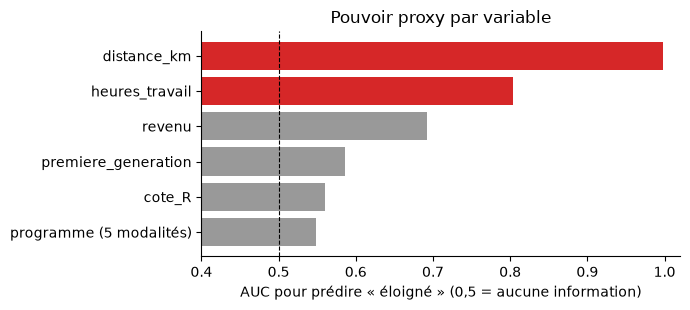

In [10]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
num = pd.DataFrame({'distance_km': df['distance_domicile_campus_km'], 'heures_travail': df['heures_travail_semaine'],
                    'revenu': df['revenu_familial_estime'], 'premiere_generation': df['premiere_generation_universitaire'],
                    'cote_R': df['cote_r_equivalent']})
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
def auc_cv(X):
    s = cross_val_predict(LogisticRegression(max_iter=3000), StandardScaler().fit_transform(X), e, cv=skf, method='decision_function')
    return roc_auc_score(e, s)
res = pd.DataFrame({'AUC (LR 1 variable)': {c: auc_cv(num[[c]]) for c in num},
                    'AUC brut (signe libre)': {c: max(roc_auc_score(e, num[c]), 1 - roc_auc_score(e, num[c])) for c in num},
                    'info. mutuelle': dict(zip(num, mutual_info_classif(num, e, random_state=SEED))),
                    'corr. avec éloigné': {c: np.corrcoef(num[c], e)[0, 1] for c in num}})
res['AUC (LR 1 variable)'] = res['AUC (LR 1 variable)'].clip(lower=0.5)
prog_d = pd.get_dummies(df['programme_etudes']).astype(float)
res.loc['programme (5 modalités)', 'AUC (LR 1 variable)'] = auc_cv(prog_d)
res = res.sort_values('AUC (LR 1 variable)', ascending=False)
print(res.round(3).to_string())
auc_sc = auc_cv(num[['cote_R', 'revenu', 'heures_travail']].assign(revenu=np.log(num['revenu'])))
auc_rh = auc_cv(num[['revenu', 'heures_travail']].assign(revenu=np.log(num['revenu'])))
score_com = Z[:, :3] @ coef[:3]
print(f"\nAUC du score du comité (R, revenu, heures pondérés par ses coefficients) : {roc_auc_score(e, -score_com):.3f}"
      f" | AUC de la combinaison revenu + heures seule : {roc_auc_score(e, -(Z[:, 1] * coef[1] + Z[:, 2] * coef[2])):.3f}")
print(f"AUC revenu + heures ensemble : {auc_rh:.3f} ; cote R + revenu + heures : {auc_sc:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
r = res['AUC (LR 1 variable)'].iloc[::-1]
ax.barh(r.index, r.values, color=[C_ELOIGNE if v > 0.7 else '#999999' for v in r.values])
ax.axvline(0.5, color='k', lw=0.8, ls='--'); ax.set_xlim(0.4, 1.02)
ax.set_xlabel("AUC pour prédire « éloigné » (0,5 = aucune information)"); ax.set_title('Pouvoir proxy par variable')
plt.tight_layout(); plt.show()

In [11]:
ct = pd.crosstab(df['code_postal_3'], df['region_administrative'])
purete = ct.max(axis=1).sum() / ct.values.sum()
print(f"{ct.shape[0]} préfixes de code postal ; pureté code postal -> région : {purete:.3f}")
cp = ct.idxmax(axis=1).rename('region').to_frame().join(ct.sum(axis=1).rename('n'))
print(cp.groupby('region')['n'].agg(['count', 'sum']).rename(columns={'count': 'préfixes', 'sum': 'dossiers'}))

18 préfixes de code postal ; pureté code postal -> région : 1.000
                               préfixes  dossiers
region                                           
Bas-Saint-Laurent                     3      1293
Capitale-Nationale                    4      1999
Cote-Nord                             3      1178
Gaspesie-Iles-de-la-Madeleine         3      1529
Montreal                              5      4001


In [12]:
rows = []
for etiq, pre in [('toutes les colonnes', ()), ('sans région', ('region_administrative_',)),
                  ('sans région ni code postal', ('region_administrative_', 'code_postal_3_')),
                  ('sans région, code postal ni distance', ('region_administrative_', 'code_postal_3_', 'distance'))]:
    _, p, _ = rf_sans(pre)
    rows.append((etiq, accuracy_score(y_te, p), ecart_parite(p, g_te)))
print(pd.DataFrame(rows, columns=['retrait', 'exactitude', 'écart de parité']).round(3).to_string(index=False))

                             retrait  exactitude  écart de parité
                 toutes les colonnes       0.881            0.188
                         sans région       0.884            0.180
          sans région ni code postal       0.880            0.174
sans région, code postal ni distance       0.871            0.110


La distance et le code postal identifient la région presque parfaitement (la région est une fonction du code postal : pureté de 1,0). Les heures de travail et, plus faiblement, le revenu sont des proxys réels ; la première génération est faible ; la cote R et le programme sont quasi sans lien avec la région. Revenu et heures sont des proxys en sens opposés (le revenu est plus élevé au centre, les heures de travail plus élevées en région) : combinés dans le score du comité, leur information régionale s'annule en grande partie (AUC du score ci-dessus), d'où notre choix de les garder tous deux. Retirer des colonnes ne règle pas le problème tant que l'étiquette d'entraînement est biaisée : sans région ni code postal l'écart reste proche de 0,17 ; en retirant aussi la distance il baisse mais subsiste (heures, revenu), tandis que l'exactitude contre le comité change à peine.

## 8. Moteurs du modèle de base

Importance par permutation du modèle de base (RF complet) sur le jeu de test : baisse d'exactitude quand une colonne est mélangée. Colonnes regroupées par variable d'origine.

cote_r_equivalent                    0.3304
revenu_familial_estime               0.0133
distance_domicile_campus_km          0.0094
region_administrative                0.0084
heures_travail_semaine               0.0061
code_postal_3                        0.0010
programme_etudes                     0.0001
premiere_generation_universitaire   -0.0002


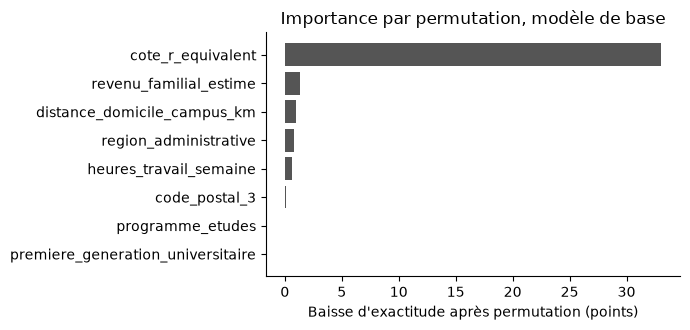

In [13]:
from sklearn.inspection import permutation_importance
Xte = X_all.loc[te_idx, cols_rf]
groups = {}
for c in cols_rf:
    key = next((p for p in CATEG if c.startswith(p + '_')), c)
    groups.setdefault(key, []).append(c)
base_acc = accuracy_score(y_te, rf.predict(Xte))
imp = {}
rs = np.random.RandomState(SEED)
for k, cs in groups.items():
    drops = []
    for _ in range(5):
        Xp = Xte.copy()
        perm_idx = rs.permutation(len(Xp))
        Xp[cs] = Xte[cs].to_numpy()[perm_idx]
        drops.append(base_acc - accuracy_score(y_te, rf.predict(Xp)))
    imp[k] = np.mean(drops)
imp = pd.Series(imp).sort_values()
print(imp.round(4).sort_values(ascending=False).to_string())
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(imp.index, imp.values * 100, color='#555555')
ax.set_xlabel("Baisse d'exactitude après permutation (points)"); ax.set_title('Importance par permutation, modèle de base')
plt.tight_layout(); plt.show()

La cote R domine nettement ; viennent ensuite le revenu, la distance et la région, avec des valeurs faibles (colonnes redondantes). La région et le code postal pèsent peu *individuellement* parce que la distance et les heures les remplacent (redondance) : l'importance faible d'une colonne n'est pas la preuve de l'absence d'effet. La mesure de l'effet régional passe par le contrefactuel (section 6), pas par l'importance des variables.

## 9. Choix de la métrique d'équité

**Deux critères.**
- *Parité démographique* : même taux d'octroi dans les deux groupes. Elle ne demande pas de savoir qui mérite.
- *Égalité des chances* : parmi les candidats qui méritent la bourse, même probabilité de l'obtenir, soit un TPR égal.

**Résultat d'impossibilité.** Si les taux de base du mérite diffèrent entre groupes et que le classement n'est pas parfait, on ne peut satisfaire à la fois la parité démographique et l'égalité des chances (Chouldechova 2017 ; Kleinberg, Mullainathan et Raghavan 2016). Il faut choisir.

**Notre choix : l'égalité des chances, mesurée contre une référence indépendante du comité.** Raisons :
1. Les groupes ont des profils légèrement différents (cote R, revenu, heures) : forcer la parité exacte reviendrait à ignorer un mérite réellement différent, ou à créer une préférence régionale inverse.
2. La pénalité mesurée (section 5) est un défaut de procédure : deux candidats de même mérite, traités différemment. L'égalité des chances cible exactement ce défaut.
3. Piège : mesurée contre `decision_octroi`, l'égalité des chances est vide de sens (section 3). Les contraintes d'équité conditionnées sur l'étiquette historique égalisent le TPR *par rapport au comité biaisé*, pas par rapport au mérite.
4. La parité démographique reste une mesure de contrôle (nous la surveillons : écart, ratio d'impact), mais l'imposer relève d'une politique d'accès, pas d'un choix de modèle.

**Cadre juridique (à valider par un juriste).**
- Charte des droits et libertés de la personne du Québec, art. 10 : la région n'est pas un motif énuméré ; l'argument est la discrimination indirecte fondée sur la « condition sociale ». Art. 86 : les programmes d'accès à l'égalité sont permis, c'est la voie légitime vers une parité démographique, par décision de politique et non par un modèle.
- Loi 25 (secteur privé), art. 12.1 : **à vérifier**. Pour une décision fondée exclusivement sur un traitement automatisé, informer la personne, lui indiquer les principaux facteurs et lui permettre de présenter ses observations. Notre sortie `explanations.csv` fournit les principaux facteurs.

## 10. Limites

- **Données synthétiques.** Les mécanismes (pénalité forfaitaire, proxys quasi parfaits) sont plus nets qu'en réalité ; les chiffres ne se transposent pas tels quels.
- **Référence cachée inconnue.** Nous ne connaissons pas l'étalon du jury. Nos références (mérite = cote R ; comité sans pénalité) sont des hypothèses, et nos mesures de fermeture de l'écart valent contre elles seulement.
- **Deux groupes seulement.** Le regroupement centre / éloigné masque des différences internes et les intersections (première génération, programme). La surveillance en tient compte (écart intersectionnel).
- **Le comité récompense le revenu et les heures de travail.** Ce sont aussi des proxys. Nous les gardons (ensemble ils ne portent presque aucune information régionale au-delà de la cote R) mais c'est un choix de valeur à débattre, non un fait neutre.
- **Étiquette biaisée.** Toute mesure par rapport à `decision_octroi` hérite du biais ; les IC et tests ci-dessus supposent des dossiers indépendants.
- **Test contrefactuel** : modèle logistique du comité, pas le comité réel ; la causalité est celle du modèle.

## Ce que fait notre correction

Le script `model_corrige.py` : (1) estime puis retire la pénalité régionale du modèle du comité (−1,90 log-cotes, cotes × 0,15), (2) réétiquette les dossiers (3 994 octrois sur 10 000, le budget historique), (3) entraîne une régression logistique sans région sur la cote R, le revenu (log) et les heures, (4) soumet la liste à un jury de validateurs, qui échange 36 dossiers sans changer le budget, (5) audite les décisions avant publication.

Résultats (10 découpages, même budget) : écart d'égalité des chances contre le comité corrigé de 0,253 (modèle de production, seuil naturel) ou 0,211 (au budget) à **0,014 ± 0,007** ; contre le mérite, de 0,247 / 0,188 à **0,010 ± 0,011**. Sur les 4 000 candidats : taux d'octroi de 39,95 % (dans la plage 36–44 %), 42,3 % au centre contre 36,5 % en région éloignée. Ces écarts se mesurent contre *nos* références, pas contre l'étalon caché.

In [14]:
print(f"Durée totale : {time.time() - T0:.0f} s")

Durée totale : 13 s
